In [2]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout


In [3]:
SAMPLE_RATE = 16000
DURATION = 1  # seconds
SAMPLES = SAMPLE_RATE * DURATION

def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    
    # Trim or pad to 1 second
    if len(audio) > SAMPLES:
        audio = audio[:SAMPLES]
    else:
        audio = np.pad(audio, (0, SAMPLES - len(audio)))

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    return mfcc.T  # (time, features)


In [4]:
DATASET_PATH = r"D:\pyton\Nari_Shakti\data\Audio_Speech_Actors_01-24"

X = []
y = []

for actor_folder in os.listdir(DATASET_PATH):
    actor_path = os.path.join(DATASET_PATH, actor_folder)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):
        if not file.endswith(".wav"):
            continue

        emotion_code = int(file.split("-")[2])
        file_path = os.path.join(actor_path, file)

        # Angry → 1
        if emotion_code == 5:
            mfcc = extract_mfcc(file_path)
            X.append(mfcc)
            y.append(1)

        # Neutral or Calm → 0
        elif emotion_code in [1, 2]:
            mfcc = extract_mfcc(file_path)
            X.append(mfcc)
            y.append(0)


480 total samples

40-60 ratio for angry to normal


In [5]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Aggressive samples:", sum(y))
print("Normal samples:", len(y) - sum(y))


X shape: (480, 32, 40)
y shape: (480,)
Aggressive samples: 192
Normal samples: 288


**Mel Frequency Cepstral Coefficients(MFCCs)** are basically a fingerprint of how a human hears sound. 

It emphasizes voice frequencies.


Removes irrelevant noise.


Compress audio into meaningful numbers.


MFCC captures tone, pitch energy. Ignores exact words and speaker identity.

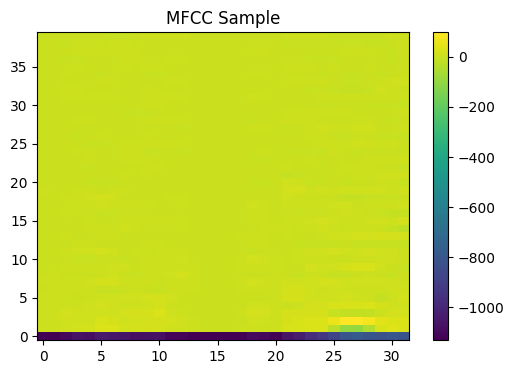

In [6]:
plt.figure(figsize=(6,4))
plt.imshow(X[0].T, aspect='auto', origin='lower')
plt.title("MFCC Sample")
plt.colorbar()
plt.show()


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

print(X_train.shape, X_test.shape)
# Run this in your Jupyter Notebook
print(f"MEAN: {np.mean(X_train)}")
print(f"STD: {np.std(X_train)}")


(384, 32, 40) (96, 32, 40)
MEAN: -19.785846710205078
STD: 145.11888122558594


We use a **1-D CNN(convolutional neural network)** because,

It captures local temporal patterns(tone,pitch). 


It is faster and lighter than RNNs and LSTMs.


Works well for on device inference.

**Sequential** creates a linear stack of layers where the output of one layer becomes input for another layer. Easy to deploy as our audio pipeline is straightforward.




In [8]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


In [9]:
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=X_train.shape[1:]), # applies 32 convolutional filters
    MaxPooling1D(2), # reduces sequence length by half, keeps only important features, prevents overfitting

    Conv1D(64, kernel_size=3, activation='relu'), # applies 64 filters builds on learned features by first layer
    GlobalAveragePooling1D(), # averages feature map across time, key reason why it works offline on a phone

    Dense(32, activation='relu'), # combines all extracted audio features, makes sense of all detected patterns together
    Dropout(0.3), # disables 30% of neurons during training, prevents overfitting

    Dense(1, activation='sigmoid') # outputs a value between 0 and 1
])

model.compile(
    optimizer='adam', # adaptive learning rate and works well with small dataset
    loss='binary_crossentropy', # since output is sigmoid
    metrics=['accuracy']
)

model.summary()


d:\pyton\Nari_Shakti\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 13, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

The below code trains the neural network to learn the difference between agressive and normal voice using supervised learning. 

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=16
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5859 - loss: 0.6784 - val_accuracy: 0.6042 - val_loss: 0.6658
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5990 - loss: 0.6707 - val_accuracy: 0.6042 - val_loss: 0.6479
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6042 - loss: 0.6601 - val_accuracy: 0.6354 - val_loss: 0.6425
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5885 - loss: 0.6678 - val_accuracy: 0.6562 - val_loss: 0.6391
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6432 - loss: 0.6452 - val_accuracy: 0.6562 - val_loss: 0.6278
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6615 - loss: 0.6515 - val_accuracy: 0.6667 - val_loss: 0.6121
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6667 - loss: 0.6298 - val_accuracy: 0.6250 - val_loss: 0.6442
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6406 - loss: 0.6507 - val_accuracy: 0.7604 - val_

In [11]:
model.save("agression-model.keras")
model.export("saved_model")

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 40), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2321197569168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321246478864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321246479440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321246478096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321246478672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321246480208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321246480016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321246479248: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [13]:
# Convert SavedModel to TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")

tflite_model = converter.convert()

# Save the .tflite file
with open("aggression_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model created successfully!")


TFLite model created successfully!


In [ ]:
# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="aggression_model.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Take one test sample
sample = X_test[0:1].astype(np.float32)

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], sample)

# Run inference
interpreter.invoke()

# Get output
output = interpreter.get_tensor(output_details[0]['index'])

print("TFLite prediction:", output)

# To check if the tflite and normal model have same accuracy
original_pred = model.predict(X_test[0:1])
print("Original model prediction:", original_pred)


TFLite prediction: [[0.6987668]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
Original model prediction: [[0.6987668]]


In [19]:
import json
import numpy as np

# Find one aggressive sample
for i in range(len(y_test)):
    if y_test[i] == 1:
        aggressive_sample = X_test[i]
        break

# Find one normal sample
for i in range(len(y_test)):
    if y_test[i] == 0:
        normal_sample = X_test[i]
        break

# Save aggressive
with open("aggressive_mfcc.json", "w") as f:
    json.dump(aggressive_sample.tolist(), f)

# Save normal
with open("normal_mfcc.json", "w") as f:
    json.dump(normal_sample.tolist(), f)

print("Exported aggressive and normal samples.")


Exported aggressive and normal samples.
